## cos𝜽* calculation at a reco-level using AK4 jets instead of AK8 jets. 

In [17]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

In [100]:
fileset = {
    'BulkGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
        },
        'metadata': {
            'is_mc': 'Events',
        },
    },
    'BulkGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/RadionToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/120000/B53216D7-B5CA-A347-A49A-5B055C71FB93.root': "Events",
        },
        'metadata': {
            'is_mc': 'Events',
        },
    }
}

In [101]:
# This step takes some time because it is loading the events
test_dataset = 'BulkGravToWW'
events = NanoEventsFactory.from_root(
    fileset[test_dataset]['files'],
    entry_stop = 10000,
    metadata = fileset[test_dataset]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

# # Load RSGraviton
# rs_dataset = 'RSGravToWW'
# rs_events = NanoEventsFactory.from_root(
#     fileset[rs_dataset]['files'],
#     entry_stop=1000,
#     metadata=fileset[rs_dataset]['metadata'],
#     schemaclass=NanoAODSchema,
#     delayed=False,
# ).events()

#### ––– *Step 1: Tight Lepton Selection* –––

In [102]:
muons = events.Muon
electrons = events.Electron

# -- Tight lepton selection --
tight_muon = muons[
    (muons.pt > 30) & 
    (abs(muons.eta) < 2.4) & 
    (muons.tightId)
]

print(len(ak.flatten(tight_muon)), 'out of' ,len(ak.flatten(muons)), 'muons pass the tight selection')

tight_electron = electrons[
    (electrons.pt > 35) & 
    (abs(electrons.eta) < 2.4) & 
    (electrons.cutBased >= 3)
]

print(len(ak.flatten(tight_electron)), 'out of' ,len(ak.flatten(electrons)), 'electrons pass the tight selection')


# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_muon.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_electron.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

2471 out of 6387 muons pass the tight selection
1945 out of 8997 electrons pass the tight selection


In [103]:
# Thresholds
electron_pt_threshold = 40
muon_pt_threshold = 40
pt_miss_threshold = 40

# Tight leptons (using previous selections)
muons_tight = tight_muon[tight_muon.pt > muon_pt_threshold]
electrons_tight = tight_electron[tight_electron.pt > electron_pt_threshold]

# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events passed the tight lepton selection and loose veto.")

3117 events passed the tight lepton selection and loose veto.


In [104]:
# -- Merge leptons into a single collection --
tight_leptons = ak.with_name(
    ak.concatenate([tight_muon, tight_electron], axis=1),
    "PtEtaPhiMCandidate"
)
print(len(ak.flatten(tight_leptons)))

4416


#### ––– *Step 2: AK4 jet cleaning* –––

In [105]:
# Select AK4 jets (baseline)
ak4_jets = events.Jet[(events.Jet.pt > 30) & (abs(events.Jet.eta) < 2.4)]

# Select AK8 jets (for overlap removal)
ak8_jets = events.FatJet[(events.FatJet.pt > 200) & (abs(events.FatJet.eta) < 2.4)]

# -- Helper function for ΔR --
def delta_r_fct(obj1, obj2):
    delta_phi = np.abs(obj1.phi - obj2.phi)
    delta_phi = np.where(delta_phi > np.pi, 2*np.pi - delta_phi, delta_phi)
    delta_eta = obj1.eta - obj2.eta
    return np.sqrt(delta_eta**2 + delta_phi**2)

# --- ΔR cleaning against tight leptons ---
pairs_ak4_lep = ak.cartesian({"jet": ak4_jets, "lep": tight_leptons}, axis=1, nested=True)
delta_r_lep = delta_r_fct(pairs_ak4_lep.jet, pairs_ak4_lep.lep)
cleanmask_lep = ak.all(delta_r_lep > 0.8, axis=2)
ak4_jets_lepclean = ak4_jets[cleanmask_lep]

# --- ΔR cleaning against AK8 jets ---
pairs_ak4_ak8 = ak.cartesian({"ak4": ak4_jets_lepclean, "ak8": ak8_jets}, axis=1, nested=True)
delta_r_ak8 = delta_r_fct(pairs_ak4_ak8.ak4, pairs_ak4_ak8.ak8)
cleanmask_ak8 = ak.all(delta_r_ak8 > 0.8, axis=2)

# Final cleaned AK4 jets
ak4_jets_clean = ak4_jets_lepclean[cleanmask_ak8]

<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_178/87388857.py:26: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Jet $\eta$')
/tmp/ipykernel_178/87388857.py:28: SyntaxWarning: invalid escape sequence '\e'
  plt.title('AK4 Jet $\eta$')


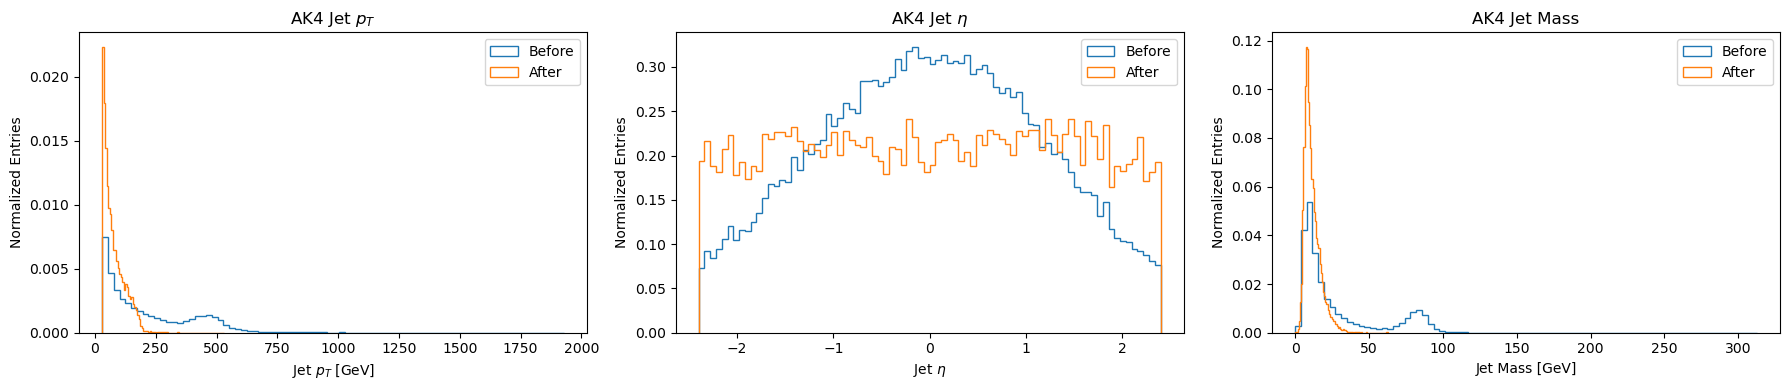

In [106]:
# Before cleaning
pt_before = ak.flatten(ak4_jets.pt)
eta_before = ak.flatten(ak4_jets.eta)
mass_before = ak.flatten(ak4_jets.mass)

# After cleaning
pt_after = ak.flatten(ak4_jets_clean.pt)
eta_after = ak.flatten(ak4_jets_clean.eta)
mass_after = ak.flatten(ak4_jets_clean.mass)

plt.figure(figsize=(18, 4))

# pT
plt.subplot(1, 3, 1)
plt.hist(pt_before, bins=80, histtype='step', label='Before', density=True)
plt.hist(pt_after, bins=80, histtype='step', label='After', density=True)
plt.xlabel('Jet $p_T$ [GeV]')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet $p_T$')
plt.legend()

# Eta
plt.subplot(1, 3, 2)
plt.hist(eta_before, bins=80, histtype='step', label='Before', density=True)
plt.hist(eta_after, bins=80, histtype='step', label='After', density=True)
plt.xlabel('Jet $\eta$')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet $\eta$')
plt.legend()

# Mass
plt.subplot(1, 3, 3)
plt.hist(mass_before, bins=80, histtype='step', label='Before', density=True)
plt.hist(mass_after, bins=80, histtype='step', label='After', density=True)
plt.xlabel('Jet Mass [GeV]')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jet Mass')
plt.legend()

plt.tight_layout()
plt.show()

#### *––– Step 3: Define Semi-Leptonic and Hadronic Categories Using AK4 Jets –––*

In [107]:
# define hadronic and semi-leptonic masks based on leptons
n_tight_muons = ak.num(tight_muon)
n_tight_electrons = ak.num(tight_electron)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(ak4_jets_clean) >= 2)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(ak4_jets_clean) >= 4))

# Apply masks to events and AK4 jets
ak4_jets_had = ak4_jets_clean[fully_hadronic_mask]
ak4_jets_semi = ak4_jets_clean[semi_leptonic_mask]

#### *––– Step 4: Pair jets per event –––*

In [108]:
# --- SEMI-LEPTONIC: use leading + subleading AK4 jets ---
ak4_jets_sl = ak4_jets_clean[ak.num(ak4_jets_clean) >= 2]
lead_ak4_sl = ak4_jets_sl[:, 0]
sublead_ak4_sl = ak4_jets_sl[:, 1]

# --- HADRONIC: best dijet pair from top 4 jets (closest to W mass) ---
ak4_jets_had = ak4_jets_clean[ak.num(ak4_jets_clean) >= 4]
ak4_top4 = ak4_jets_had[:, :4]

ak4_pairs = ak.combinations(ak4_top4, 2, fields=["j1", "j2"])
pair_masses = (ak4_pairs.j1 + ak4_pairs.j2).mass
best_idx = ak.argmax(pair_masses, axis=1)

# Clean extraction of best dijet pair (1-to-1 mapping, no jagged nesting)
j1_had = ak4_pairs.j1[best_idx]
j2_had = ak4_pairs.j2[best_idx]

#### *–––Step 5: Compute cosθ** –––

In [109]:
# --- Build Lorentz vectors for semi-leptonic ---
def build_lorentz_vectors(jets):
    return vector.array({
        "px": jets.pt * np.cos(jets.phi),
        "py": jets.pt * np.sin(jets.phi),
        "pz": jets.pt * np.sinh(jets.eta),
        "E":  np.sqrt((jets.pt * np.cosh(jets.eta))**2 + jets.mass**2),
    })

In [110]:
# -- Semi-leptonic category: leading + subleading AK4 jets --
q1_sl = build_lorentz_vectors(lead_ak4_sl)
q2_sl = build_lorentz_vectors(sublead_ak4_sl)
ak4pairs_sl = list(zip(q1_sl, q2_sl))  # List of (vec1, vec2) tuples

# -- Fully hadronic category: best dijet pair from top 4 jets --
# Flatten the selected jets (from best dijet pair)
j1_had_flat = ak.flatten(j1_had)
j2_had_flat = ak.flatten(j2_had)
# Now safely build Lorentz vectors
q1_had = build_lorentz_vectors(j1_had_flat)
q2_had = build_lorentz_vectors(j2_had_flat)
# Form (vec1, vec2) pairs
ak4pairs_had = list(zip(q1_had, q2_had))

In [111]:
# -- Compute cos(θ*) for Given AK4 Jet Pairs --
def compute_cos_theta_star_from_ak4pairs(jet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(jet_pairs):
        try:
            w_lab = vec1 + vec2
            if w_lab.mass < np.abs(1e-3) or w_lab.E <= np.abs(1e-6):
                n_skipped += 1
                continue

            # Boost vec1 into W rest frame
            q1_rest = vec1.boost_beta3(-w_lab.to_beta3())

            # Compute unit 3-momentum vector of q1 in W rest frame
            q_vec = np.array([q1_rest.px, q1_rest.py, q1_rest.pz])
            q_unit = q_vec / np.linalg.norm(q_vec)

            # Compute unit boost direction vector (W momentum in lab)
            w_vec = np.array([w_lab.px, w_lab.py, w_lab.pz])
            w_unit = w_vec / np.linalg.norm(w_vec)

            # Cos(theta*) = angle between decay product and boost axis
            cos_theta = np.dot(q_unit, w_unit)

            cos_theta_star.append(cos_theta)
            n_success += 1

        except Exception:
            n_skipped += 1

    print(f"[{category_name}] Computed cosθ* for {n_success} AK4 jet pairs, Skipped: {n_skipped}")
    
    if len(cos_theta_star) > 0:
        cos_array = np.array(cos_theta_star)
        print(f"[{category_name}] cosθ* range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
        print(f"[{category_name}] Histogram counts (neg, zero, pos): "
              f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")

    return np.array(cos_theta_star)

In [112]:
cos_theta_star_sl = compute_cos_theta_star_from_ak4pairs(ak4pairs_sl, category_name="AK4 Semi-leptonic")
cos_theta_star_had = compute_cos_theta_star_from_ak4pairs(ak4pairs_had, category_name="AK4 Fully hadronic")

[AK4 Semi-leptonic] Computed cosθ* for 3235 AK4 jet pairs, Skipped: 0
[AK4 Semi-leptonic] cosθ* range: min = -0.953, max = 1.000
[AK4 Semi-leptonic] Histogram counts (neg, zero, pos): 917, 0, 2318
[AK4 Fully hadronic] Computed cosθ* for 2598 AK4 jet pairs, Skipped: 0
[AK4 Fully hadronic] cosθ* range: min = -0.931, max = 0.968
[AK4 Fully hadronic] Histogram counts (neg, zero, pos): 624, 0, 1974


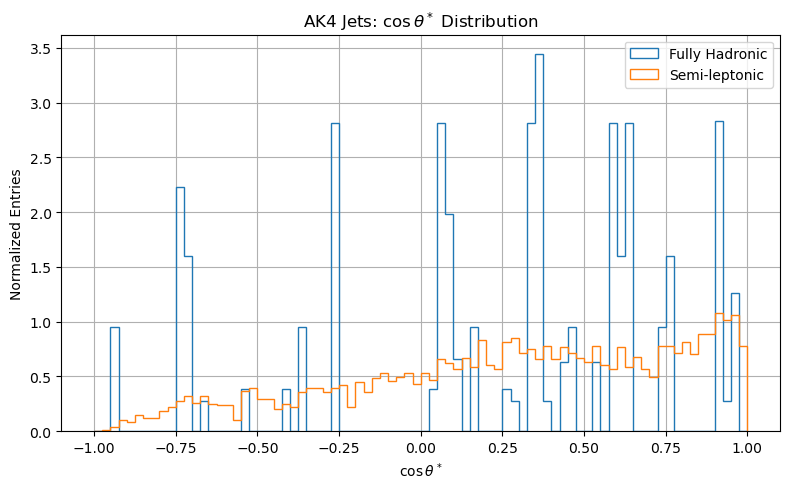

In [113]:
plt.figure(figsize=(8, 5))

# Histogram overlays (normalized)
plt.hist(cos_theta_star_had, bins=80, range=(-1, 1), histtype='step', label='Fully Hadronic', density=True)
plt.hist(cos_theta_star_sl, bins=80, range=(-1, 1), histtype='step', label='Semi-leptonic', density=True)

plt.xlabel(r'$\cos\theta^*$')
plt.ylabel('Normalized Entries')
plt.title('AK4 Jets: $\\cos\\theta^*$ Distribution')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# print("lead_ak4_sl example:", ak4_jets_semi[0])
# print("ak.num(ak4_jets_semi):", ak.num(ak4_jets_semi))

In [98]:
# print(ak4_jets_semi[0].pt)  # Should match lead_ak4_sl[0].pt
# print(ak4_jets_had[0].pt)   # Should match lead_ak4_had[0].pt

In [99]:
# print("SL pt example:", lead_ak4_sl.pt)
# print("Had pt example:", lead_ak4_had.pt)